# Can a canceled order make a product look like a bestseller?
## A simple story for an online retailer

**Main finding:** A paper craft product ranks second by positive sales value, at **£168,469.60**.
Its only positive invoice is followed by an equal cancellation **12 minutes later**. Its net recorded value is **£0**.

**Audience:** The non-technical sales and stock managers of a UK online gift retailer.

**Business decision:** Which products deserve stock and promotion attention? Before using a sales ranking,
the company should check cancellations and how many invoices support each product's sales.

This analysis uses actual transactions from the UCI Online Retail dataset, dated **1 December 2010 to 9 December 2011**.
The retailer's name is not provided. This is a historical case study.

## 1. Questions and hypothesis

1. Does the bestseller list change after cancellations are included?
2. Do the top products appear on many sales invoices, or only a few?
3. How much cancellation value comes from the two largest cancellation invoices?

**Hypothesis:** A product can appear to be a bestseller because of a very large sale entry that is later canceled.
Comparing positive sales, cancellations, and invoice counts should reveal such cases.

This is an exploratory check of the records. It is not a statistical test of why customers cancel.

## 2. Read and check the data

One row is one item line on an invoice. An invoice can have several item lines.
The source defines invoice numbers starting with **C** as cancellations. Prices are in **British pounds**.

The code uses pandas for simple tables and matplotlib for charts.
Keep the notebook beside its `data` folder. The Excel file is included in the project package.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(r"D:\springboard\case studies\Retail_Storytelling")

DATA_PATH = BASE_DIR / 'data' / 'Online Retail.xlsx'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_excel(DATA_PATH, dtype={'InvoiceNo': str, 'StockCode': str})
print('Rows:', len(df))
print('Dates:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
print('Missing descriptions:', df['Description'].isna().sum())
print('Missing customer IDs:', df['CustomerID'].isna().sum())
print('Exact repeated rows:', df.duplicated().sum())

### Which records are included?

- Use product codes with five digits and optional letters, such as `22423` and `85123A`.
  This defines the product scope and leaves out separate codes for postage, fees, manual entries,
  gift vouchers, and other nonstandard codes. Some real products also use nonstandard codes, such as party bags;
  they are outside this scope. It is not a complete accounting report.
- Keep positive unit prices. Zero or negative prices are outside this sales-value analysis.
- Keep missing customer IDs because the questions are about products, not individual customers.
- Keep repeated rows. There is no unique invoice-line ID to tell whether they are duplicate entries or repeated item lines.
  This could affect totals. The paper craft example has just two distinct rows.
- Use the full available period for every chart. December 2011 is incomplete, so monthly or annual growth is not compared.

**Definitions**

| Measure | Calculation |
| --- | --- |
| Line value | Quantity × UnitPrice |
| Positive sales | Sum of line values where quantity is positive and the invoice does not start with C |
| Cancellation value | Absolute value of negative lines on C invoices |
| Net recorded value | Positive sales minus cancellation value |
| Sales invoices | Number of different positive invoice numbers containing that product |

Net recorded value is a simple total from these records. It is **not profit**, and cancellation value is not proof of defective products or preventable losses.

In [2]:
# Keep the regular product codes and positive prices.
product_code = df['StockCode'].str.fullmatch(r'[0-9]{5}[A-Za-z]*')
products = df[product_code & (df['UnitPrice'] > 0)].copy()
products['LineValue'] = products['Quantity'] * products['UnitPrice']

is_cancellation = products['InvoiceNo'].str.upper().str.startswith('C')
sales = products[(~is_cancellation) & (products['Quantity'] > 0)].copy()
cancellations = products[is_cancellation & (products['Quantity'] < 0)].copy()
cancellations['CancellationValue'] = -cancellations['LineValue']

print('Positive sales lines:', len(sales))
print('Cancellation lines:', len(cancellations))
print('Lines outside these two groups:', len(df) - len(sales) - len(cancellations))
print('Missing descriptions in included lines:',
      sales['Description'].isna().sum() + cancellations['Description'].isna().sum())

Positive sales lines: 527725
Cancellation lines: 8704
Lines outside these two groups: 5480
Missing descriptions in included lines: 0


## 3. Does the bestseller list change?

I grouped the records by product code. Product descriptions are only labels because a description can change.
The chart shows the **six largest products by positive sales value**, in the same order for both measures.

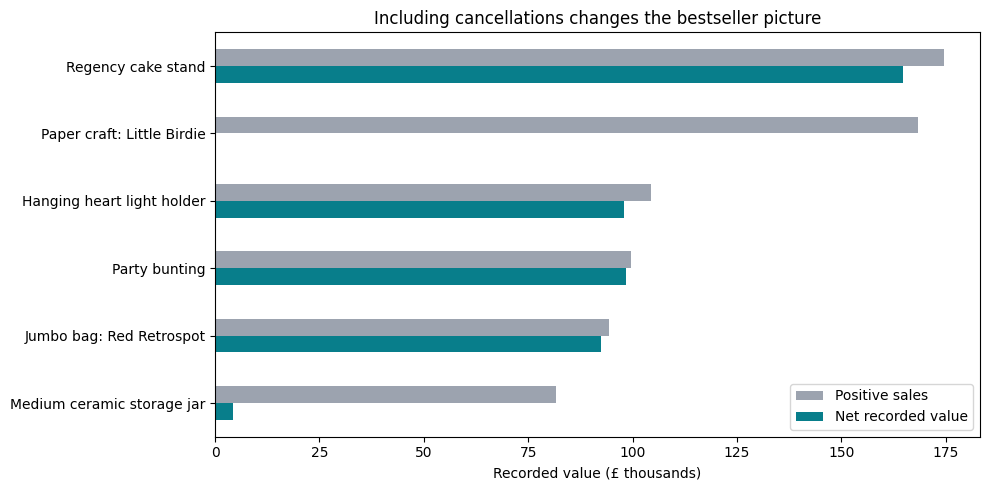

,Product,Positive sales,Cancellation value,Net recorded value
StockCode,,,,
22423,Regency cake stand,174484.74,9722.55,164762.19
23843,Paper craft: Little Birdie,168469.60,168469.60,0.00
85123A,Hanging heart light holder,104518.80,6624.30,97894.50
47566,Party bunting,99504.33,1201.35,98302.98
85099B,Jumbo bag: Red Retrospot,94340.05,1984.02,92356.03
23166,Medium ceramic storage jar,81700.92,77479.64,4221.28


In [3]:
summary = pd.DataFrame({
    'Positive sales': sales.groupby('StockCode')['LineValue'].sum(),
    'Cancellation value': cancellations.groupby('StockCode')['CancellationValue'].sum(),
    'Sales invoices': sales.groupby('StockCode')['InvoiceNo'].nunique()
}).fillna(0)
summary['Net recorded value'] = summary['Positive sales'] - summary['Cancellation value']
summary['Description'] = sales.groupby('StockCode')['Description'].first()
top6 = summary.sort_values('Positive sales', ascending=False).head(6).copy()

# Short names make the chart easier to read.
names = {
    '22423': 'Regency cake stand',
    '23843': 'Paper craft: Little Birdie',
    '85123A': 'Hanging heart light holder',
    '47566': 'Party bunting',
    '85099B': 'Jumbo bag: Red Retrospot',
    '23166': 'Medium ceramic storage jar'
}
top6['Product'] = top6.index.map(names)

ax = (top6.set_index('Product')[['Positive sales', 'Net recorded value']] / 1000).plot.barh(
    figsize=(10, 5), color=['#9ca3af', '#087e8b'])
ax.invert_yaxis()
ax.set_title('Including cancellations changes the bestseller picture')
ax.set_xlabel('Recorded value (£ thousands)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_sales_and_cancellations.png', dpi=160)
plt.show()

display(top6[['Product', 'Positive sales', 'Cancellation value', 'Net recorded value']].round(2))

### What the chart shows

- **Paper craft:** £168,469.60 in positive sales is offset by the same cancellation value, leaving **£0**.
- **Medium ceramic storage jar:** £81,700.92 in positive sales becomes **£4,221.28** after cancellations.
- **Regency cake stand:** still leads these products, with **£164,762.19** in net recorded value.

**Business meaning:** A ranking based only on positive sales could give a manager a misleading picture of which products are selling well.

## 4. How many invoices support those sales?

A large sales total can come from many invoices or from one unusually large invoice.
I counted each invoice only once per product, even if it contains repeated lines for that product.

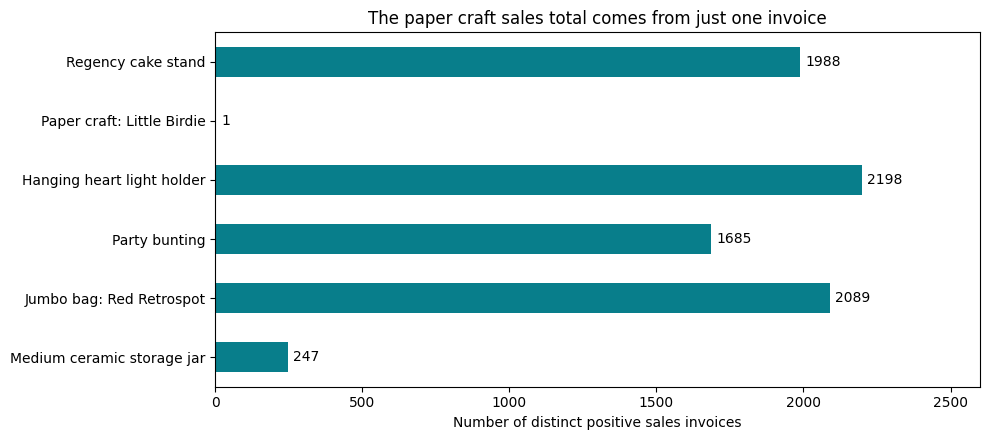

In [4]:
ax = top6.set_index('Product')['Sales invoices'].plot.barh(
    figsize=(10, 4.5), color='#087e8b')
ax.invert_yaxis()
ax.set_title('The paper craft sales total comes from just one invoice')
ax.set_xlabel('Number of distinct positive sales invoices')
ax.set_ylabel('')
ax.set_xlim(0, 2600)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '02_sales_invoice_counts.png', dpi=160)
plt.show()

### What the chart shows

The paper craft product appears on **one** positive invoice. The cake stand appears on **1,988**,
and the hanging heart light holder on **2,198**.

This does not count unique customers. It shows how broadly the sales value is spread across invoices.
The paper craft result needs a closer look before being used to justify a large stock purchase.

## 5. What happened to the paper craft entry?

The two rows below are the complete records for product code **23843** in the selected product data.

In [5]:
paper_craft = products[products['StockCode'] == '23843'].sort_values('InvoiceDate')
display(paper_craft[['InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice', 'LineValue']])

minutes = (paper_craft['InvoiceDate'].iloc[1] - paper_craft['InvoiceDate'].iloc[0]).total_seconds() / 60
same_customer = paper_craft['CustomerID'].nunique() == 1
print('Minutes between the entries:', int(minutes))
print('Same recorded customer ID:', same_customer)

,InvoiceNo,InvoiceDate,Quantity,UnitPrice,LineValue
540421,581483,2011-12-09 09:15:00,80995,2.08,168469.6
540422,C581484,2011-12-09 09:27:00,-80995,2.08,-168469.6


Minutes between the entries: 12
Same recorded customer ID: True


The first entry records **80,995 units at £2.08** at **09:15 on 9 December 2011**.
The second records **-80,995 units at the same price** at **09:27**. Both have the same customer ID.

This is consistent with a full reversal of that sale entry. The data do not include a reason or an explicit link between the invoices.
I cannot tell whether it was an entry correction or a genuine order cancellation.

## 6. Are a few invoices dominating cancellation value?

I added the selected product cancellation lines within each invoice, then compared the two largest invoices with all the others.

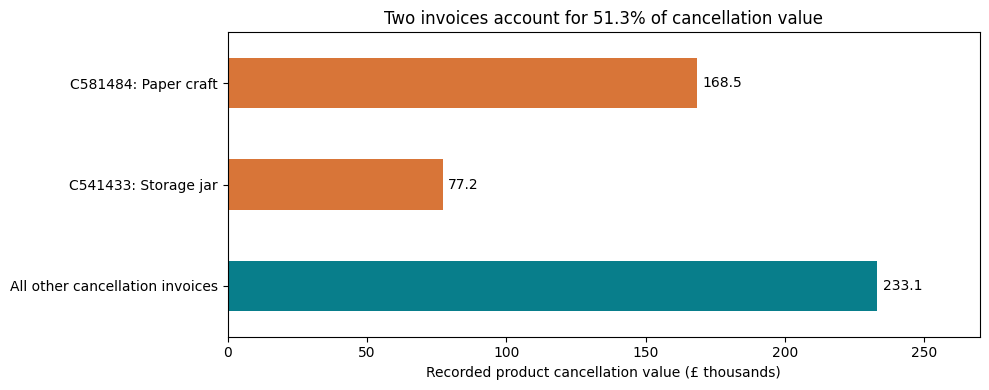

Total selected product cancellation value: £478,724.18
Value on the two largest cancellation invoices: £245,653.20
Share of cancellation value: 51.3 %


In [6]:
invoice_values = cancellations.groupby('InvoiceNo')['CancellationValue'].sum().sort_values(ascending=False)
largest_two = invoice_values.head(2)
share = 100 * largest_two.sum() / invoice_values.sum()

comparison = pd.Series({
    'C581484: Paper craft': largest_two.loc['C581484'],
    'C541433: Storage jar': largest_two.loc['C541433'],
    'All other cancellation invoices': invoice_values.iloc[2:].sum()
})
ax = (comparison / 1000).plot.barh(figsize=(10, 4), color=['#d87538', '#d87538', '#087e8b'])
ax.invert_yaxis()
ax.set_title(f'Two invoices account for {share:.1f}% of cancellation value')
ax.set_xlabel('Recorded product cancellation value (£ thousands)')
ax.set_ylabel('')
ax.set_xlim(0, 270)
ax.bar_label(ax.containers[0], fmt='%.1f', padding=4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_cancellation_concentration.png', dpi=160)
plt.show()

print('Total selected product cancellation value: £' + format(invoice_values.sum(), ',.2f'))
print('Value on the two largest cancellation invoices: £' + format(largest_two.sum(), ',.2f'))
print('Share of cancellation value:', round(share, 1), '%')

### What the chart shows

Only **two cancellation invoices account for 51.3%** of the **£478,724.18** recorded product cancellation value.
Together they total **£245,653.20**.

This is a share of money recorded on cancellation invoices, **not a customer cancellation rate**.
A few very large records can strongly affect the overall picture.

## 7. Conclusion and recommendation

The records support the hypothesis: a very large sale entry that is canceled can make a product appear to be a bestseller.
The clearest example is paper craft, which ranks second by positive sales value but has no net recorded value in this period.

**My recommendation to the sales and stock managers:**

1. Show **positive sales, cancellation value, net recorded value, and invoice count** together in the product report.
2. Review the two large cancellation invoices with the order-processing team. Check the reason before drawing conclusions about either product.
3. Use recent confirmed orders, stock availability, and product margins before deciding what to reorder or promote.

**Follow-up hypothesis:** A review of unusually large orders before they enter a bestseller report may reduce misleading product rankings.
To investigate this, record cancellation reasons, link cancellations to original orders, and compare the report before and after review.
The current dataset cannot measure the savings from that change.

**Takeaway:** Check what is behind a bestseller ranking before spending money on it.

## 8. Limitations

- This is one retailer's historical data. Many customers are wholesalers, so large quantities are not automatically errors.
- Cancellation invoices do not identify the cause. They cannot establish product quality, customer dissatisfaction, or fraud.
- Except for inspecting the paper craft example, I did not match cancellation invoices to original sales. Some related sales may fall outside the period.
- The code-based product scope excludes nonstandard codes, and repeated rows are retained. These choices affect the totals.
- The data have no product costs or inventory levels. Net recorded value is not profit or a complete stocking recommendation.

In [7]:
# Save the product summary for later reference.
summary.to_csv(RESULTS_DIR / 'product_summary.csv')